#Classification Problem Dataiku Assessment

## Exploratory Data Analysis

In [1]:
# Importing Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# View all columns
pd.set_option('display.max_columns', None)

In [3]:
# Loading Dataset
df = pd.read_csv('census_income_learn.csv', names=['Age', 'Class_of_worker', 'industry_code', 'occupation_code',
                                                   'education', 'wage_ph', 'Enrolled_in_edu_LW',
                                                   'marital_status', 'major_industry_code', 'major_occupation_code',
                                                   'race', 'hispanic_origin', 'sex', 'mem_labor_union', 'reason_unemployment',
                                                   'FT_PT','capital_gains', 'capital_losses', 'dividends_from_stocks',
                                                   'tax_filer_status', 'region_of_previous_residence',
                                                   'state_of_previous_residence', 'detailed_household_and_family_stat',
                                                   'detailed_household_summary_in_household', 'instance_weight',
                                                   'migration_codechange_in_msa', 'migration_codechange_in_reg',
                                                   'migration_codemove_within_reg', 'live_in_this_house_1yr_ago',
                                                   'migration_prev_res_in_sunbelt', 'num_persons_worked_for_employer',
                                                   'family_members_under_18', 'country_of_birth_F',
                                                   'country_of_birth_M', 'country_of_birth_self', 'citizenship',
                                                   'own_business_self_employed', 'fill_inc_q_for_vet_admin',
                                                   'vets_benefits', 'weeks_worked_in_year', 'year', 'income_level'])

In [4]:
df.head()

,Age,Class_of_worker,industry_code,occupation_code,education,wage_ph,Enrolled_in_edu_LW,marital_status,major_industry_code,major_occupation_code,race,hispanic_origin,sex,mem_labor_union,reason_unemployment,FT_PT,capital_gains,capital_losses,dividends_from_stocks,tax_filer_status,region_of_previous_residence,state_of_previous_residence,detailed_household_and_family_stat,detailed_household_summary_in_household,instance_weight,migration_codechange_in_msa,migration_codechange_in_reg,migration_codemove_within_reg,live_in_this_house_1yr_ago,migration_prev_res_in_sunbelt,num_persons_worked_for_employer,family_members_under_18,country_of_birth_F,country_of_birth_M,country_of_birth_self,citizenship,own_business_self_employed,fill_inc_q_for_vet_admin,vets_benefits,weeks_worked_in_year,year,income_level
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Other Rel 18+ ever marr not in subfamily,Other relative of householder,1700.09,?,?,?,Not in universe under 1 year old,?,0,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Head of household,South,Arkansas,Householder,Householder,1053.55,MSA to MSA,Same county,Same county,No,Yes,1,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,Asian or Pacific Islander,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Child 18+ never marr Not in a subfamily,Child 18 or older,991.95,?,?,?,Not in universe under 1 year old,?,0,Not in universe,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1758.14,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1069.16,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.


In [5]:
# Info on the type of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199523 entries, 0 to 199522
Data columns (total 42 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   Age                                      199523 non-null  int64  
 1   Class_of_worker                          199523 non-null  object 
 2   industry_code                            199523 non-null  int64  
 3   occupation_code                          199523 non-null  int64  
 4   education                                199523 non-null  object 
 5   wage_ph                                  199523 non-null  int64  
 6   Enrolled_in_edu_LW                       199523 non-null  object 
 7   marital_status                           199523 non-null  object 
 8   major_industry_code                      199523 non-null  object 
 9   major_occupation_code                    199523 non-null  object 
 10  race                            

###Checking categories and counts for the variables

In [6]:
df.Class_of_worker.value_counts()

,count
Class_of_worker,
Not in universe,100245
Private,72028
Self-employed-not incorporated,8445
Local government,7784
State government,4227
Self-employed-incorporated,3265
Federal government,2925
Never worked,439
Without pay,165


In [7]:
df.education.value_counts()

,count
education,
High school graduate,48407
Children,47422
Some college but no degree,27820
Bachelors degree(BA AB BS),19865
7th and 8th grade,8007
10th grade,7557
11th grade,6876
Masters degree(MA MS MEng MEd MSW MBA),6541
9th grade,6230


In [8]:
df.major_occupation_code.value_counts()

,count
major_occupation_code,
Not in universe,100684
Adm support including clerical,14837
Professional specialty,13940
Executive admin and managerial,12495
Other service,12099
Sales,11783
Precision production craft & repair,10518
Machine operators assmblrs & inspctrs,6379
Handlers equip cleaners etc,4127


In [9]:
df.sex.value_counts()

,count
sex,
Female,103984
Male,95539


In [10]:
df.FT_PT.value_counts()

,count
FT_PT,
Children or Armed Forces,123769
Full-time schedules,40736
Not in labor force,26808
PT for non-econ reasons usually FT,3322
Unemployed full-time,2311
PT for econ reasons usually PT,1209
Unemployed part- time,843
PT for econ reasons usually FT,525


In [11]:
df.tax_filer_status.value_counts()

,count
tax_filer_status,
Nonfiler,75094
Joint both under 65,67383
Single,37421
Joint both 65+,8332
Head of household,7426
Joint one under 65 & one 65+,3867


In [12]:
df.citizenship.value_counts()

,count
citizenship,
Native- Born in the United States,176992
Foreign born- Not a citizen of U S,13401
Foreign born- U S citizen by naturalization,5855
Native- Born abroad of American Parent(s),1756
Native- Born in Puerto Rico or U S Outlying,1519


In [13]:
df.income_level.value_counts()

,count
income_level,
- 50000.,187141
50000+.,12382


In [14]:
df.capital_gains.describe()

,capital_gains
count,199523.00000
mean,434.71899
std,4697.53128
min,0.00000
25%,0.00000
50%,0.00000
75%,0.00000
max,99999.00000


In [15]:
df.capital_losses.describe()

,capital_losses
count,199523.000000
mean,37.313788
std,271.896428
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,4608.000000


###Data Visualisations

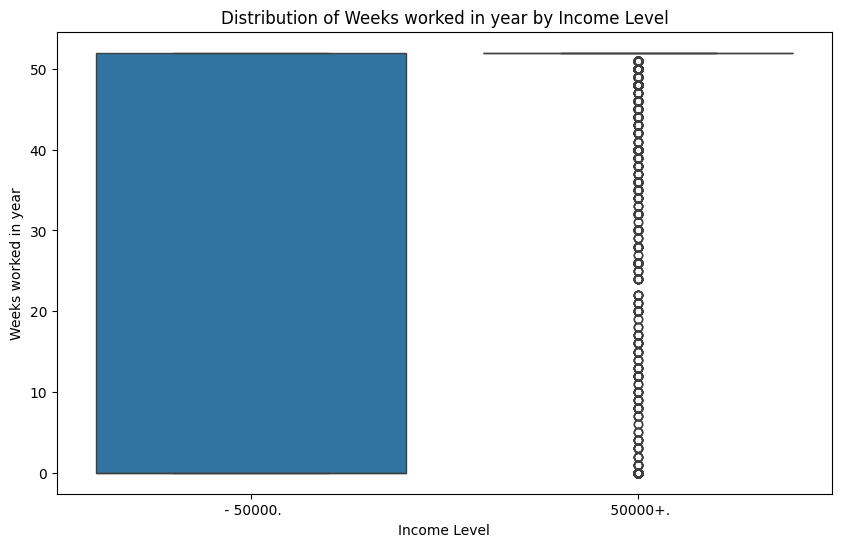

In [16]:
#Boxplot for Weeks worked in year
plt.figure(figsize=(10, 6))
sns.boxplot(x='income_level', y='weeks_worked_in_year', data=df)
plt.title('Distribution of Weeks worked in year by Income Level')
plt.xlabel('Income Level')
plt.ylabel('Weeks worked in year')
plt.show()

In [17]:
#Binary encoding for sex and income_level
df['sex'] = df['sex'].apply(lambda x: 1 if x == ' Male' else 0)
df['income_level'] = df['income_level'].apply(lambda x: 1 if x == ' 50000+.' else 0)

In [18]:
# True Percentage of people earning >50k
weighted_mean = (df['income_level'] * df['instance_weight']).sum() / df['instance_weight'].sum()
print(f"Weighted % earning >50K: {weighted_mean * 100:.2f}%")


Weighted % earning >50K: 6.41%


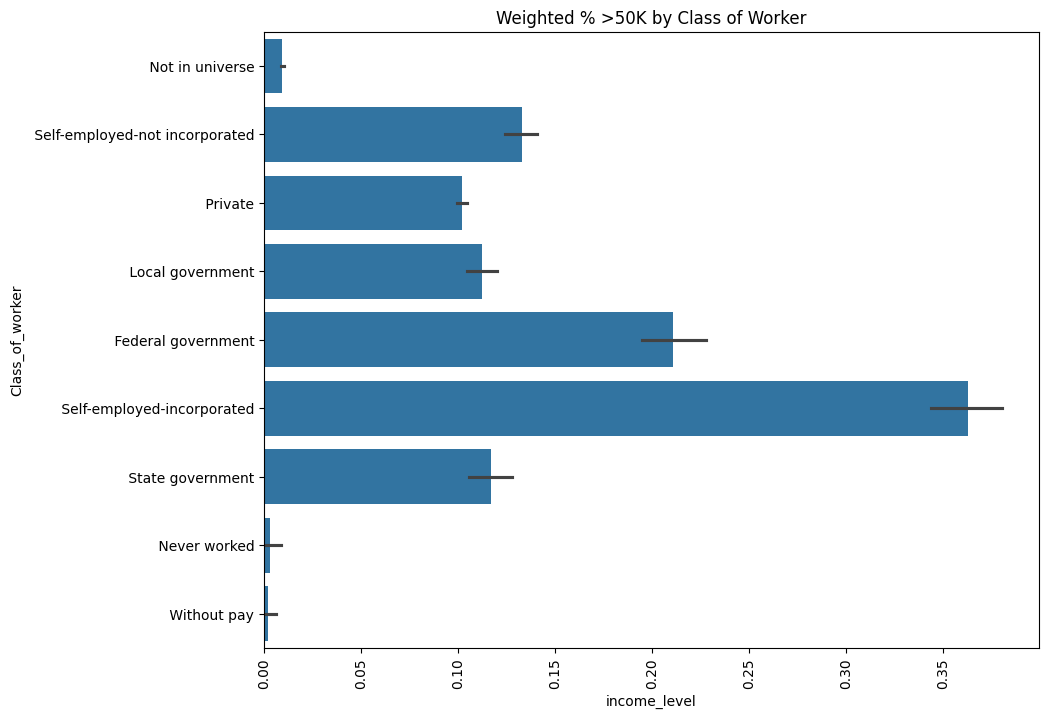

In [19]:
# Plotting Weighted % >50k by Class of Worker

plt.figure(figsize=(10,8))
sns.barplot(data=df, y='Class_of_worker', x='income_level', weights=df['instance_weight'])
plt.xticks(rotation=90)
plt.title('Weighted % >50K by Class of Worker')
plt.show()

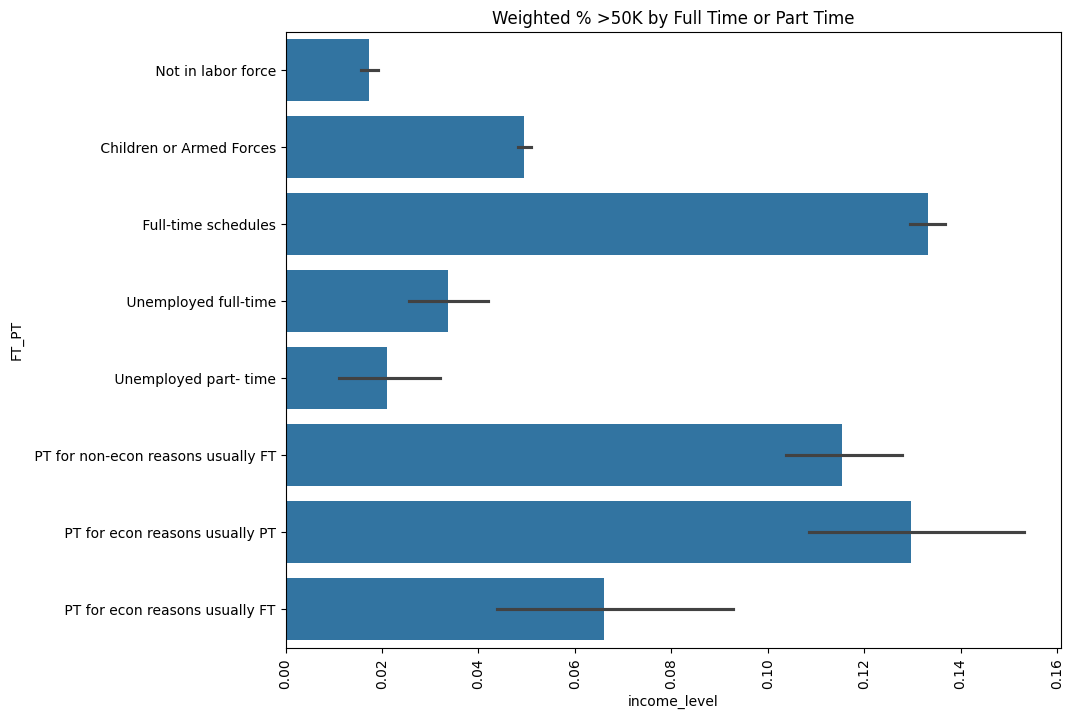

In [20]:
# Plotting Weighted % >50k by Full Time or Part Time

plt.figure(figsize=(10,8))
sns.barplot(data=df, y='FT_PT', x='income_level', weights=df['instance_weight'])
plt.xticks(rotation=90)
plt.title('Weighted % >50K by Full Time or Part Time')
plt.show()

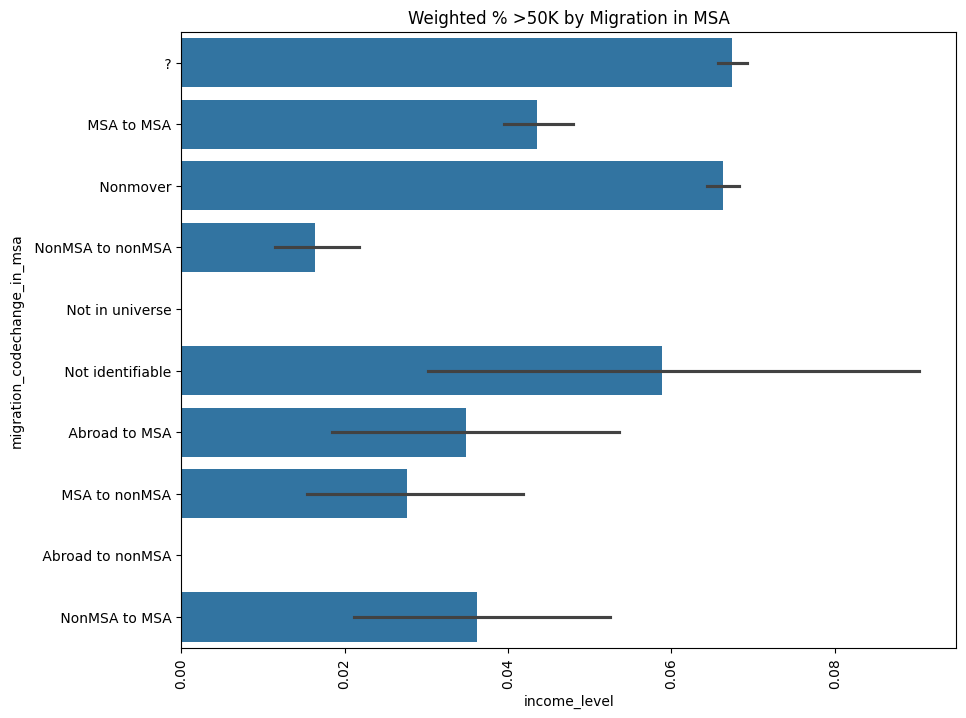

In [21]:
# Plotting Weighted % >50k by Migration in MSA

plt.figure(figsize=(10,8))
sns.barplot(data=df, y='migration_codechange_in_msa', x='income_level', weights=df['instance_weight'])
plt.xticks(rotation=90)
plt.title('Weighted % >50K by Migration in MSA')
plt.show()

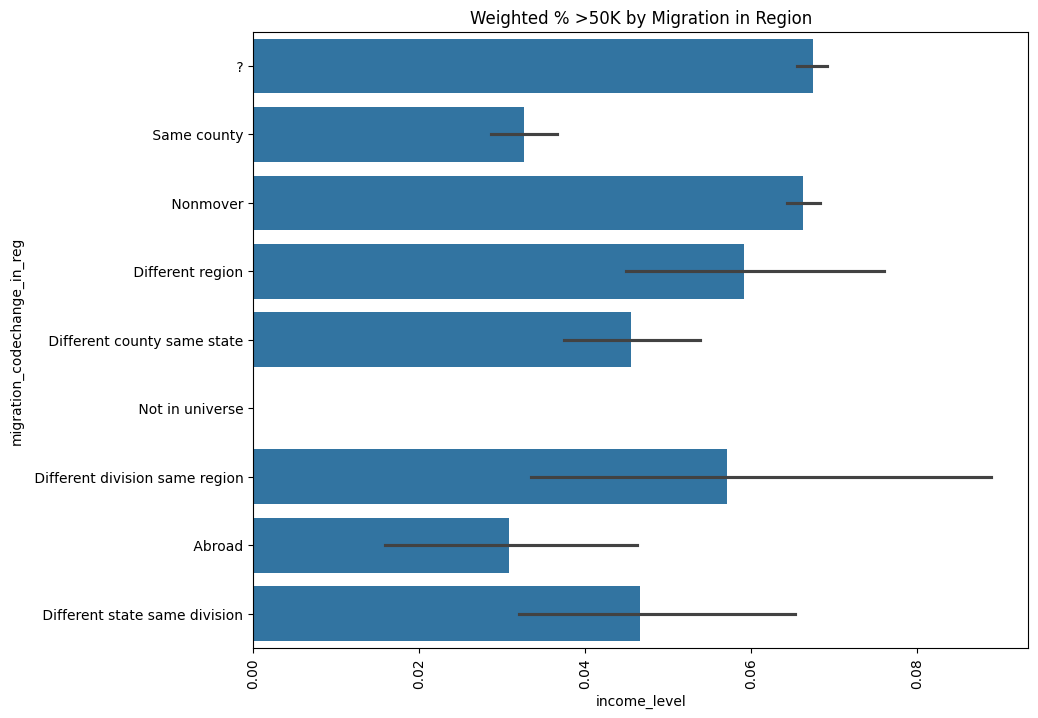

In [22]:
# Plotting Weighted % >50k by Migration in Region

plt.figure(figsize=(10,8))
sns.barplot(data=df, y='migration_codechange_in_reg', x='income_level', weights=df['instance_weight'])
plt.xticks(rotation=90)
plt.title('Weighted % >50K by Migration in Region')
plt.show()

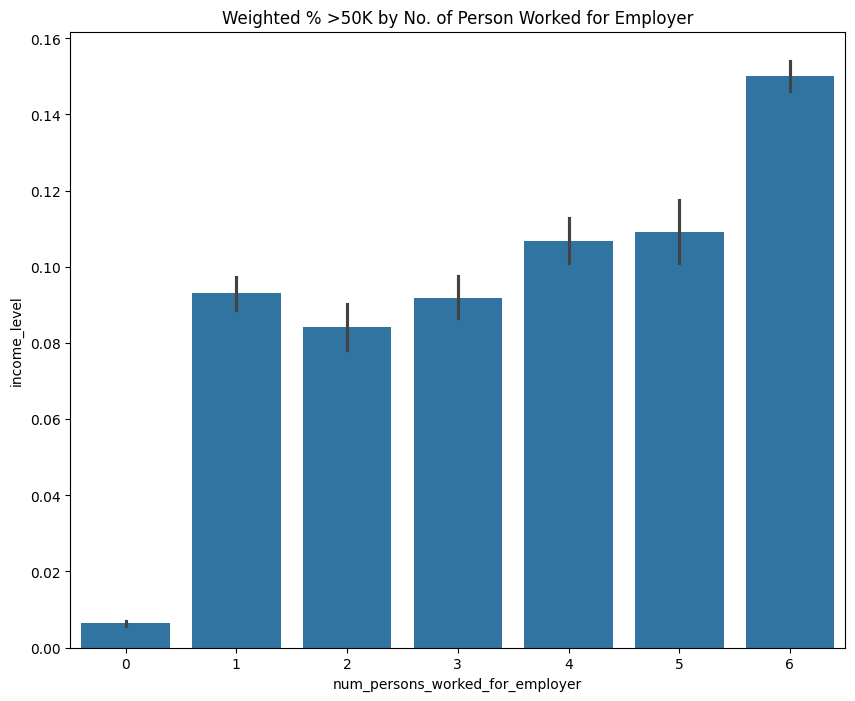

In [23]:
# Plotting Weighted % >50k by No. of Person Worked for Employer

plt.figure(figsize=(10,8))
sns.barplot(data=df, x='num_persons_worked_for_employer', y='income_level', weights=df['instance_weight'])
plt.title('Weighted % >50K by No. of Person Worked for Employer')
plt.show()

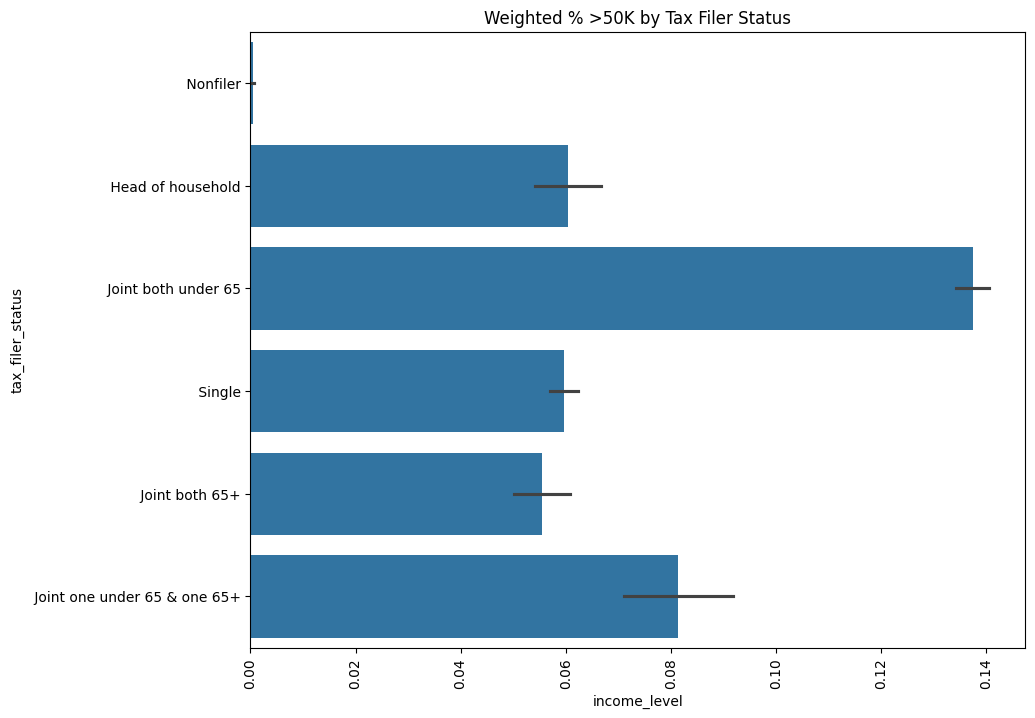

In [24]:
# Plotting Weighted % >50k by Tax Filer Status

plt.figure(figsize=(10,8))
sns.barplot(data=df, y='tax_filer_status', x='income_level', weights=df['instance_weight'])
plt.xticks(rotation=90)
plt.title('Weighted % >50K by Tax Filer Status')
plt.show()

###Data Preparation

In [25]:
# Creating bins for age group
bins = [0, 18, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 120]
labels = [
    'under_18',
    '19_20',
    '21_25',
    '26_30',
    '31_35',
    '36_40',
    '41_45',
    '46_50',
    '51_55',
    '56_60',
    '61_65',
    '65_plus'
]

df['age_group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True, include_lowest=True)

print(df[['Age', 'age_group']].head())

   Age age_group
0   73   65_plus
1   58     56_60
2   18  under_18
3    9  under_18
4   10  under_18


In [26]:
#Standardising weeks_worked_in_year
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['weeks_worked_1year'] = scaler.fit_transform(df[['weeks_worked_in_year']])
df = df.drop('weeks_worked_in_year', axis=1)

In [27]:
# One-hot Encoding and getting rid of insignificant columns that could cause bias
df = pd.concat([df.drop('age_group', axis=1),pd.get_dummies(df.age_group).add_prefix("age_")], axis=1)
df = pd.concat([df.drop('education', axis=1),pd.get_dummies(df.education).add_prefix("education_")], axis=1)
df = pd.concat([df.drop('major_occupation_code', axis=1),pd.get_dummies(df.major_occupation_code).add_prefix("occupation_")], axis=1)
df = pd.concat([df.drop('major_industry_code', axis=1),pd.get_dummies(df.major_industry_code).add_prefix("industry_")], axis=1)
df = pd.concat([df.drop('Class_of_worker', axis=1),pd.get_dummies(df.Class_of_worker).add_prefix("workclass_")], axis=1)
df = pd.concat([df.drop('marital_status', axis=1),pd.get_dummies(df['marital_status']).add_prefix("martial_status_")], axis=1)
df = pd.concat([df.drop('mem_labor_union', axis=1),pd.get_dummies(df.mem_labor_union).add_prefix("mem_labor_union_")], axis=1)
df = pd.concat([df.drop('race', axis=1),pd.get_dummies(df.race).add_prefix("race_")], axis=1)
df = pd.concat([df.drop('citizenship', axis=1),pd.get_dummies(df.citizenship).add_prefix("citizenship_")], axis=1)
df = pd.concat([df.drop('tax_filer_status', axis=1),pd.get_dummies(df['tax_filer_status']).add_prefix("tax_filer_status_")], axis=1)
df = pd.concat([df.drop('num_persons_worked_for_employer', axis=1),pd.get_dummies(df['num_persons_worked_for_employer']).add_prefix("num_persons_worked_for_employer_")], axis=1)
df = pd.concat([df.drop('detailed_household_summary_in_household', axis=1),pd.get_dummies(df['detailed_household_summary_in_household']).add_prefix("detailed_household_summary_in_household_")], axis=1)
df = df.drop('Age', axis=1)
df = df.drop('wage_ph', axis=1)
df = df.drop('industry_code', axis=1)
df = df.drop('occupation_code', axis=1)
df = df.drop('Enrolled_in_edu_LW', axis=1)
df = df.drop('hispanic_origin', axis=1)
df = df.drop('reason_unemployment', axis=1)
df = df.drop('FT_PT', axis=1)
df = df.drop('region_of_previous_residence', axis=1)
df = df.drop('state_of_previous_residence', axis=1)
df = df.drop('detailed_household_and_family_stat', axis=1)
df = df.drop('instance_weight', axis=1)
df = df.drop('migration_codechange_in_msa', axis=1)
df = df.drop('migration_codechange_in_reg', axis=1)
df = df.drop('migration_codemove_within_reg', axis=1)
df = df.drop('live_in_this_house_1yr_ago', axis=1)
df = df.drop('migration_prev_res_in_sunbelt', axis=1)
df = df.drop('family_members_under_18', axis=1)
df = df.drop('country_of_birth_F', axis=1)
df = df.drop('country_of_birth_M', axis=1)
df = df.drop('country_of_birth_self', axis=1)
df = df.drop('own_business_self_employed', axis=1)
df = df.drop('fill_inc_q_for_vet_admin', axis=1)
df = df.drop('vets_benefits', axis=1)
df = df.drop('year', axis=1)

In [28]:
# Importing resample to sort class imbalance
from sklearn.utils import resample

# Separate majority and minority classes
df_majority = df[df['income_level'] == 0]
df_minority = df[df['income_level'] == 1]

# Downsample majority class
df_majority_downsampled = resample(
    df_majority,
    replace=False,            # sample without replacement
    n_samples=len(df_minority), # match minority class count
    random_state=42           # reproducible results
)

# Combine minority with downsampled majority
df_undersampled = pd.concat([df_majority_downsampled, df_minority])

# Shuffle if desired
df_undersampled = df_undersampled.sample(frac=1, random_state=42).reset_index(drop=True)

df = df_undersampled.copy()

print(df['income_level'].value_counts())

income_level
1    12382
0    12382
Name: count, dtype: int64


In [29]:
df.head()

,sex,capital_gains,capital_losses,dividends_from_stocks,income_level,weeks_worked_1year,age_under_18,age_19_20,age_21_25,age_26_30,age_31_35,age_36_40,age_41_45,age_46_50,age_51_55,age_56_60,age_61_65,age_65_plus,education_ 10th grade,education_ 11th grade,education_ 12th grade no diploma,education_ 1st 2nd 3rd or 4th grade,education_ 5th or 6th grade,education_ 7th and 8th grade,education_ 9th grade,education_ Associates degree-academic program,education_ Associates degree-occup /vocational,education_ Bachelors degree(BA AB BS),education_ Children,education_ Doctorate degree(PhD EdD),education_ High school graduate,education_ Less than 1st grade,education_ Masters degree(MA MS MEng MEd MSW MBA),education_ Prof school degree (MD DDS DVM LLB JD),education_ Some college but no degree,occupation_ Adm support including clerical,occupation_ Armed Forces,occupation_ Executive admin and managerial,occupation_ Farming forestry and fishing,occupation_ Handlers equip cleaners etc,occupation_ Machine operators assmblrs & inspctrs,occupation_ Not in universe,occupation_ Other service,occupation_ Precision production craft & repair,occupation_ Private household services,occupation_ Professional specialty,occupation_ Protective services,occupation_ Sales,occupation_ Technicians and related support,occupation_ Transportation and material moving,industry_ Agriculture,industry_ Armed Forces,industry_ Business and repair services,industry_ Communications,industry_ Construction,industry_ Education,industry_ Entertainment,industry_ Finance insurance and real estate,industry_ Forestry and fisheries,industry_ Hospital services,industry_ Manufacturing-durable goods,industry_ Manufacturing-nondurable goods,industry_ Medical except hospital,industry_ Mining,industry_ Not in universe or children,industry_ Other professional services,industry_ Personal services except private HH,industry_ Private household services,industry_ Public administration,industry_ Retail trade,industry_ Social services,industry_ Transportation,industry_ Utilities and sanitary services,industry_ Wholesale trade,workclass_ Federal government,workclass_ Local government,workclass_ Never worked,workclass_ Not in universe,workclass_ Private,workclass_ Self-employed-incorporated,workclass_ Self-employed-not incorporated,workclass_ State government,workclass_ Without pay,martial_status_ Divorced,martial_status_ Married-A F spouse present,martial_status_ Married-civilian spouse present,martial_status_ Married-spouse absent,martial_status_ Never married,martial_status_ Separated,martial_status_ Widowed,mem_labor_union_ No,mem_labor_union_ Not in universe,mem_labor_union_ Yes,race_ Amer Indian Aleut or Eskimo,race_ Asian or Pacific Islander,race_ Black,race_ Other,race_ White,citizenship_ Foreign born- Not a citizen of U S,citizenship_ Foreign born- U S citizen by naturalization,citizenship_ Native- Born abroad of American Parent(s),citizenship_ Native- Born in Puerto Rico or U S Outlying,citizenship_ Native- Born in the United States,tax_filer_status_ Head of household,tax_filer_status_ Joint both 65+,tax_filer_status_ Joint both under 65,tax_filer_status_ Joint one under 65 & one 65+,tax_filer_status_ Nonfiler,tax_filer_status_ Single,num_persons_worked_for_employer_0,num_persons_worked_for_employer_1,num_persons_worked_for_employer_2,num_persons_worked_for_employer_3,num_persons_worked_for_employer_4,num_persons_worked_for_employer_5,num_persons_worked_for_employer_6,detailed_household_summary_in_household_ Child 18 or older,detailed_household_summary_in_household_ Child under 18 ever married,detailed_household_summary_in_household_ Child under 18 never married,detailed_household_summary_in_household_ Group Quarters- Secondary individual,detailed_household_summary_in_household_ Householder,detailed_household_summary_in_household_ Nonrelative of householder,detailed_household_summary_in_household_ Other relative of householder,detailed_household_summary_in_household_ Spouse of househol

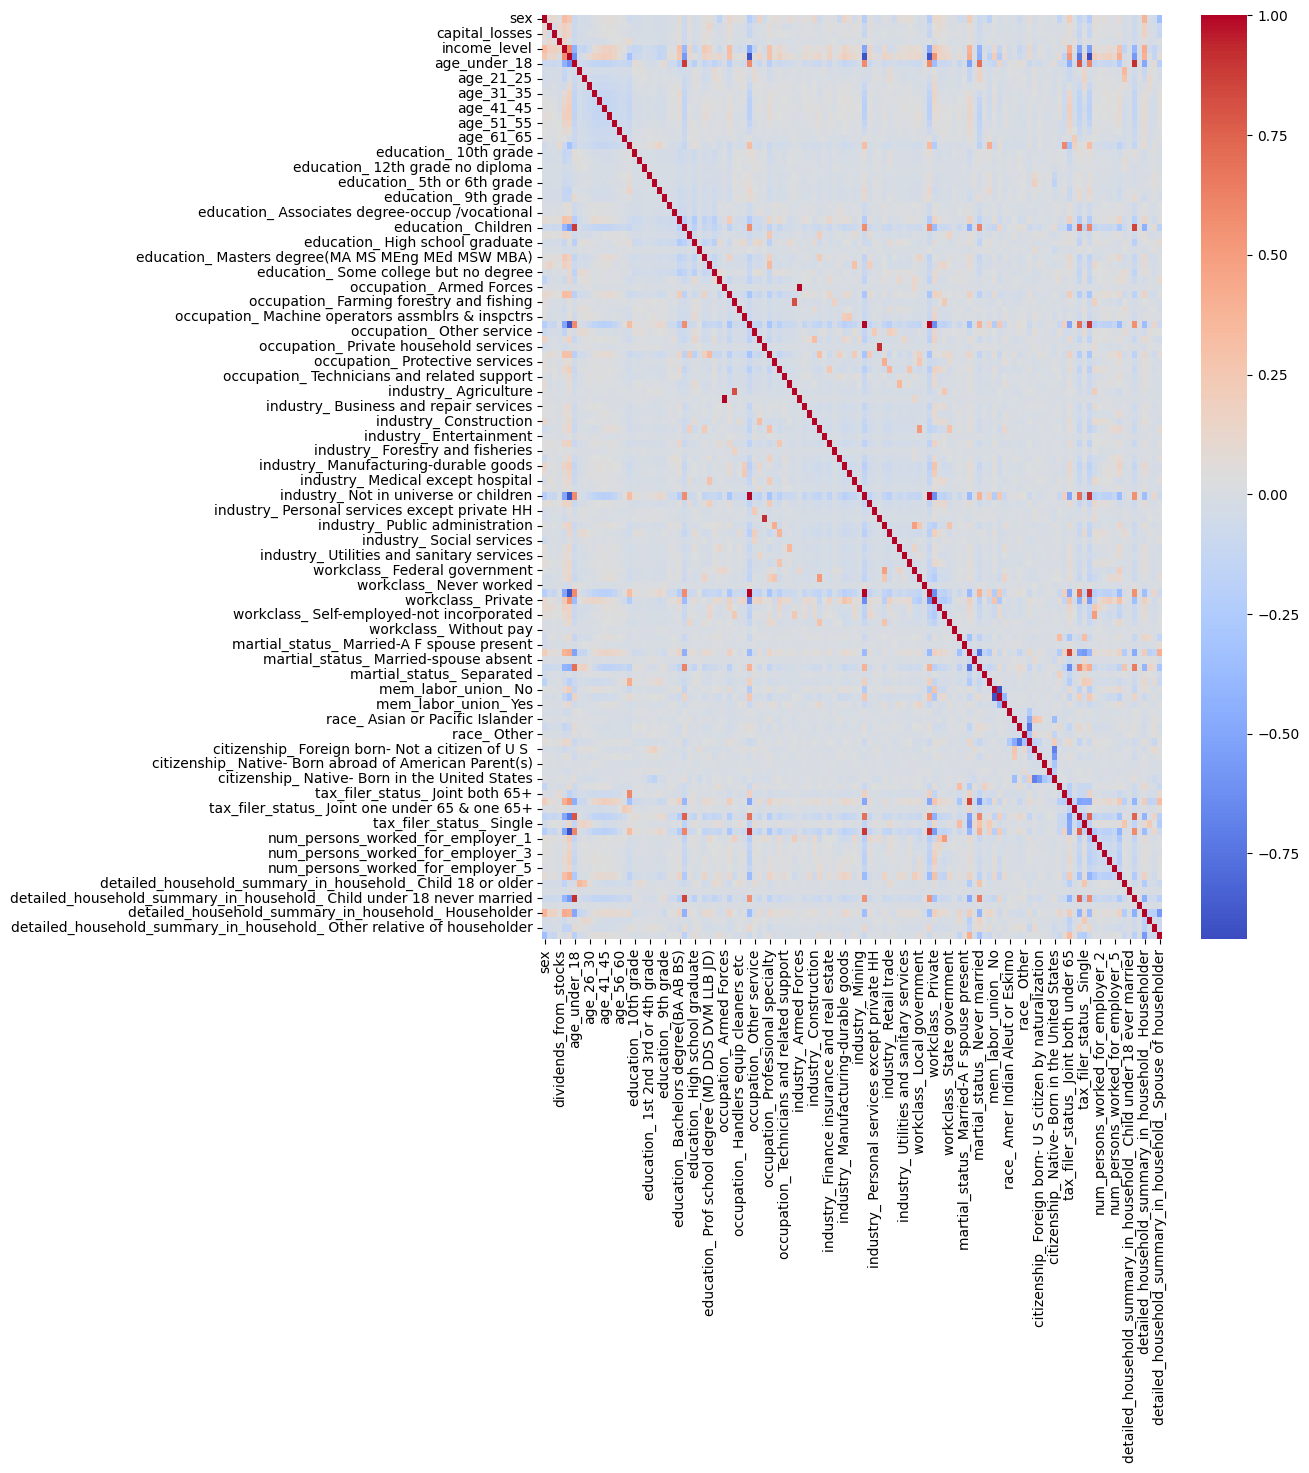

In [30]:
# Plotting a correlation heatmap
plt.figure(figsize=(10,12))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.show()

In [31]:
# Getting rid of 80% of least correlated variables to understand the data better
correlations = df.corr()['income_level'].abs()
sorted_correlations = correlations.sort_values()
number_cols_to_drop = int(0.8 * len(df.columns))
cols_to_drop = sorted_correlations.iloc[:number_cols_to_drop].index
df_dropped = df.drop(cols_to_drop, axis=1)

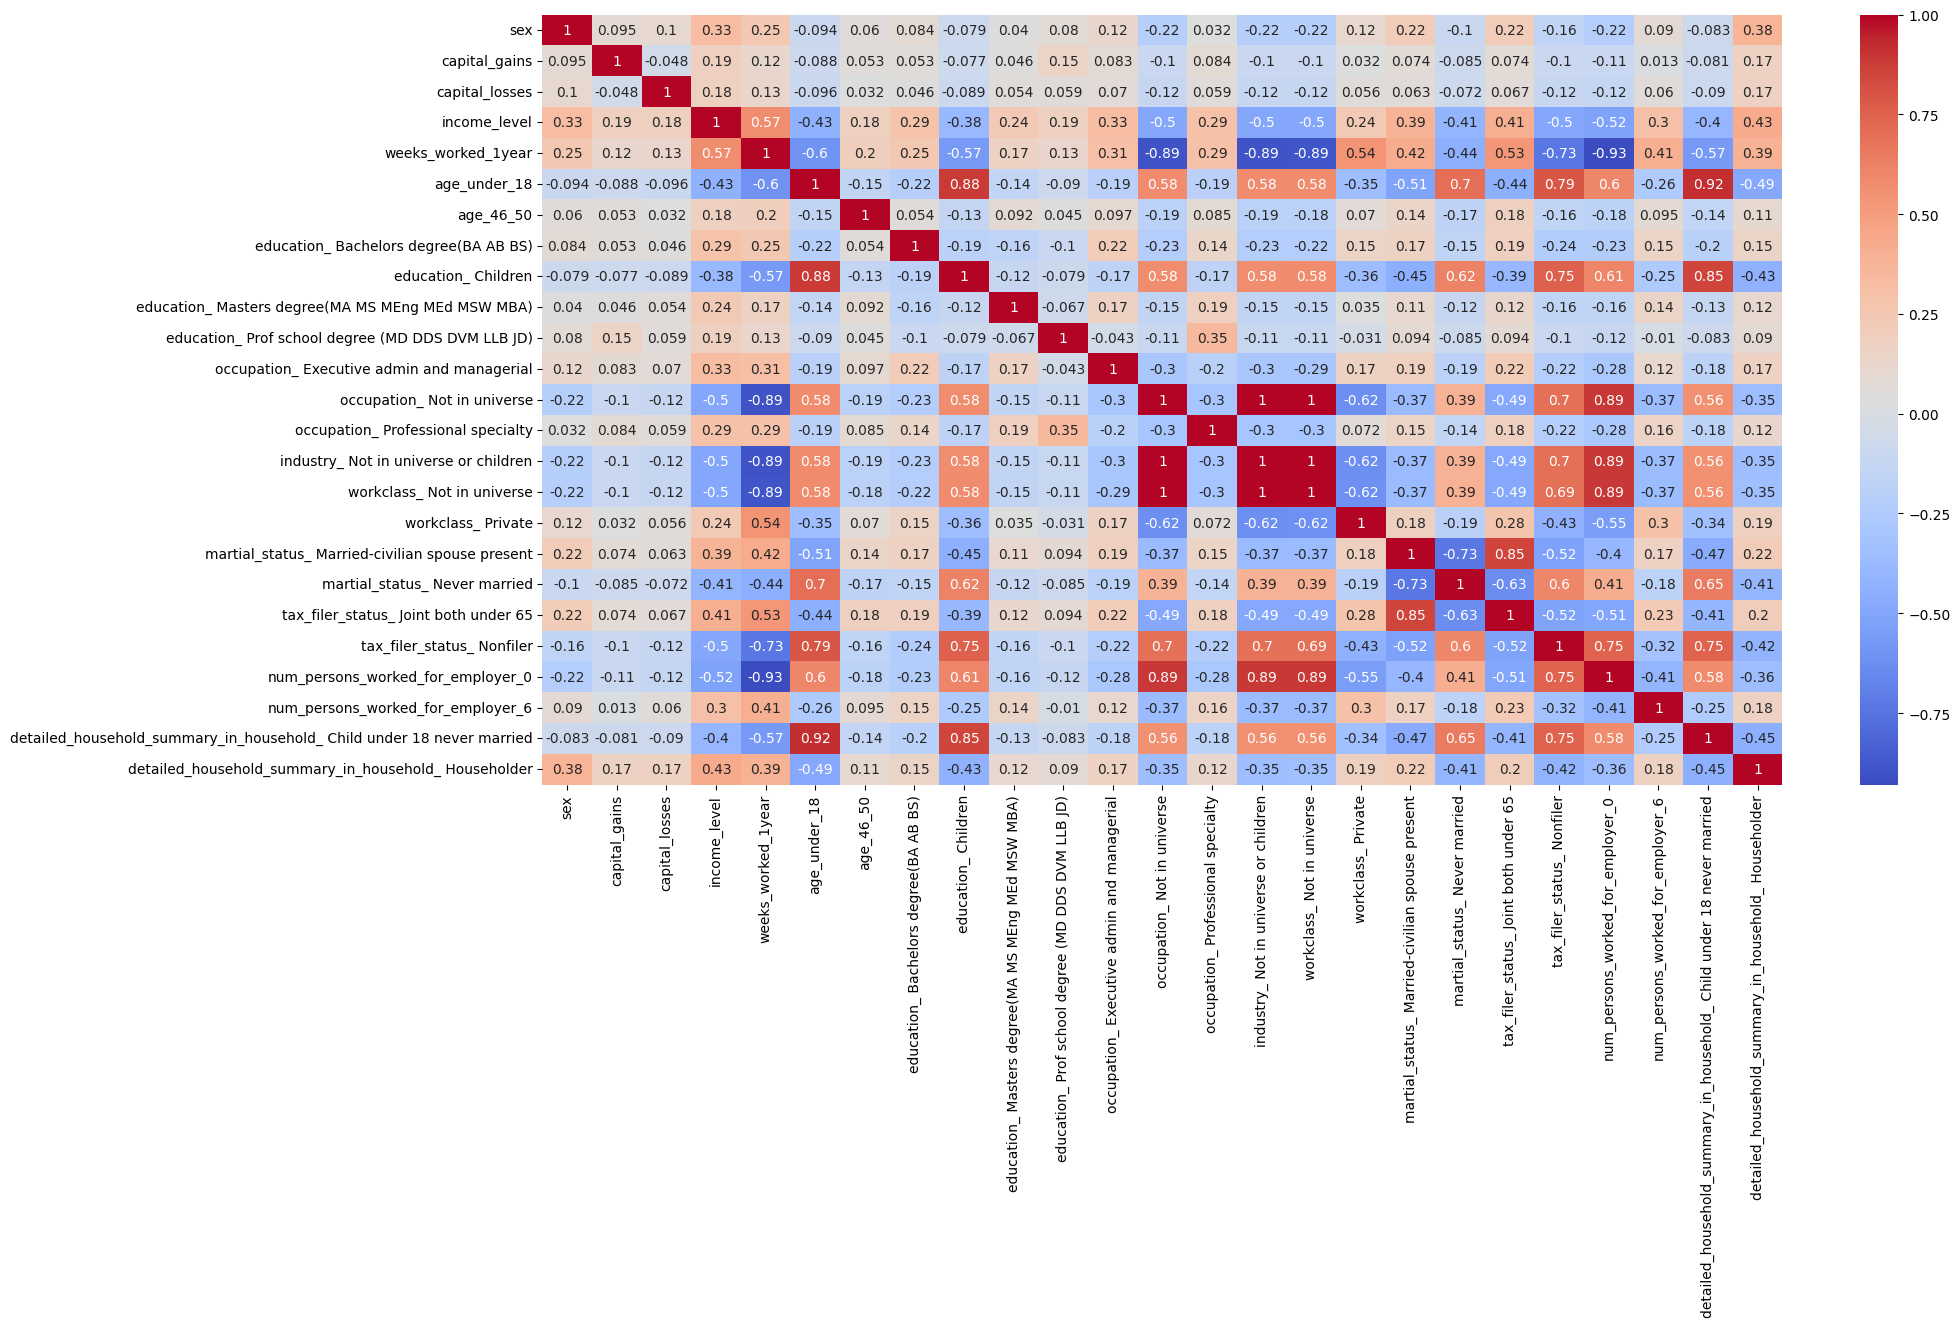

In [32]:
# Plotting the heatmap
plt.figure(figsize=(20,10))
sns.heatmap(df_dropped.corr(), annot=True, cmap='coolwarm')
plt.show()

##Data Modeling

In [33]:
# Import the Scikit-Learn
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Replace with your actual column names
X = df.drop('income_level', axis=1)
y = df['income_level']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 1. Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.84      0.87      2477
           1       0.85      0.90      0.87      2476

    accuracy                           0.87      4953
   macro avg       0.87      0.87      0.87      4953
weighted avg       0.87      0.87      0.87      4953

Random Forest Accuracy: 0.87038158691702


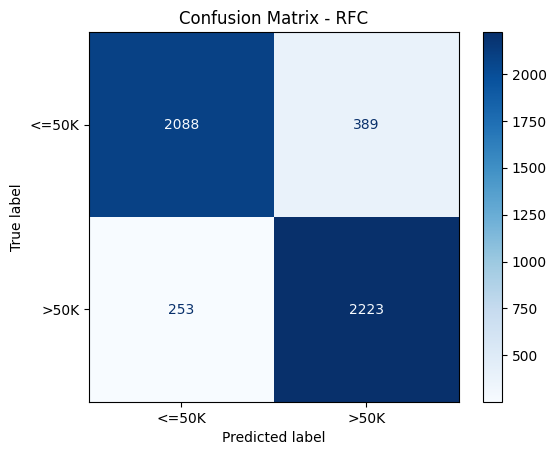

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict on your test set
y_pred = rf.predict(X_test)

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix with labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<=50K', '>50K'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - RFC")
plt.show()


In [35]:
# Creating dictionary for feature importances (Random Forest)
importances = dict(zip(rf.feature_names_in_, rf.feature_importances_))
importances = {k: v for k, v in sorted(importances.items(), key=lambda x: x[1], reverse=True)}

In [36]:
importance_df = pd.DataFrame(list(importances.items()), columns=['feature', 'importance'])

importance_df.head(15)

,feature,importance
0,weeks_worked_1year,0.082200
1,dividends_from_stocks,0.071889
2,num_persons_worked_for_employer_0,0.045575
3,sex,0.040757
4,detailed_household_summary_in_household_ House...,0.039787
5,capital_gains,0.035893
6,occupation_ Not in universe,0.033206
7,tax_filer_status_ Nonfiler,0.026316
8,martial_status_ Never married,0.021639
9,workclass_ Not in universe,0.021414


In [37]:
# 2. XGBoost (binary classification)
xgb = XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print("XGBoost Classification Report:\n", classification_report(y_test, y_pred_xgb))
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [23:02:46] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.86      0.88      2477
           1       0.87      0.89      0.88      2476

    accuracy                           0.88      4953
   macro avg       0.88      0.88      0.88      4953
weighted avg       0.88      0.88      0.88      4953

XGBoost Accuracy: 0.8778518069856652


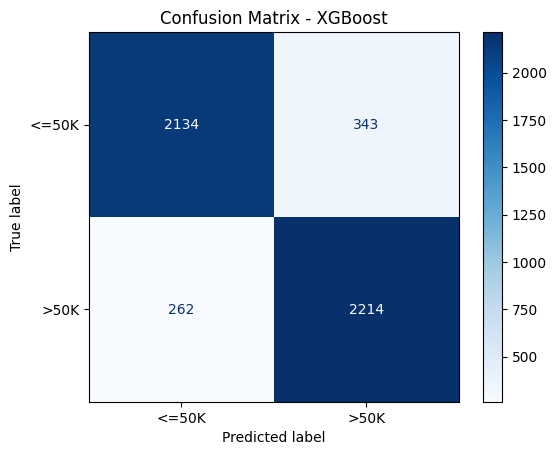

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict on your test set
y_pred = xgb.predict(X_test)

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix with labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<=50K', '>50K'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - XGBoost")
plt.show()


In [39]:
# Creating dictionary for feature importances (XGBoost)
importances = dict(zip(xgb.feature_names_in_, xgb.feature_importances_))
importances = {k: v for k, v in sorted(importances.items(), key=lambda x: x[1], reverse=True)}
importance_df = pd.DataFrame(list(importances.items()), columns=['feature', 'importance'])

importance_df.head(15)

,feature,importance
0,tax_filer_status_ Nonfiler,0.130965
1,weeks_worked_1year,0.086703
2,occupation_ Other service,0.056452
3,age_under_18,0.039387
4,occupation_ Executive admin and managerial,0.026761
5,sex,0.026044
6,occupation_ Professional specialty,0.024357
7,dividends_from_stocks,0.021168
8,education_ Prof school degree (MD DDS DVM LLB JD),0.020269
9,martial_status_ Never married,0.020041


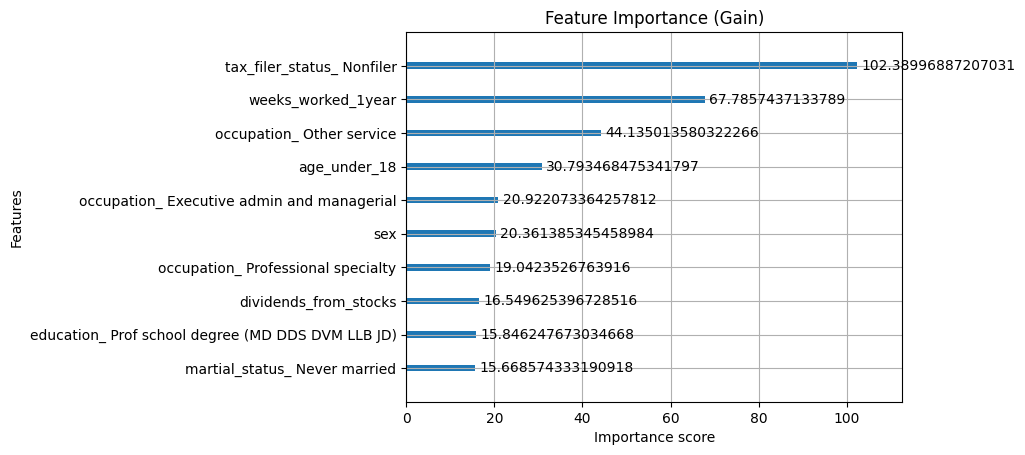

In [40]:
# gain, most predictive features
from xgboost import plot_importance

plot_importance(xgb, importance_type='gain', max_num_features=10)
plt.title('Feature Importance (Gain)')
plt.show()

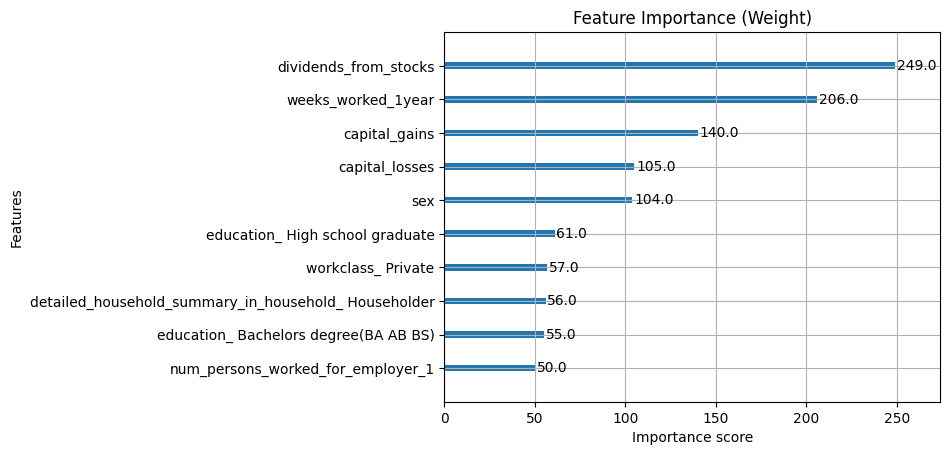

In [41]:
# weight, features used most often to split
from xgboost import plot_importance

plot_importance(xgb, max_num_features=10)
plt.title('Feature Importance (Weight)')
plt.show()

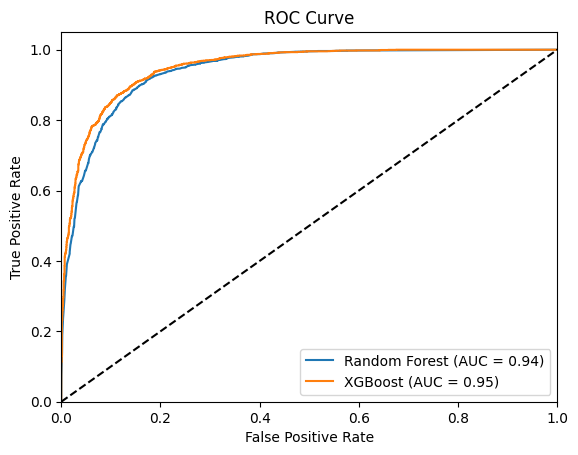

In [42]:
# Plotting ROC AUC curves
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities for the positive class (class 1: >50K)
rf_probs = rf.predict_proba(X_test)[:, 1]
xgb_probs = xgb.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC for each model
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs, pos_label=1)
roc_auc_rf = auc(fpr_rf, tpr_rf)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs, pos_label=1)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# Plot both ROC curves
plt.figure()
plt.plot(fpr_rf, tpr_rf, label='Random Forest (AUC = %0.2f)' % roc_auc_rf)
plt.plot(fpr_xgb, tpr_xgb, label='XGBoost (AUC = %0.2f)' % roc_auc_xgb)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()


##Scoring on final dataset

###Preparing Test dataset to be the same as train

In [43]:
# Loading Dataset
df = pd.read_csv('census_income_test.csv', names=['Age', 'Class_of_worker', 'industry_code', 'occupation_code',
                                                   'education', 'wage_ph', 'Enrolled_in_edu_LW',
                                                   'marital_status', 'major_industry_code', 'major_occupation_code',
                                                   'race', 'hispanic_origin', 'sex', 'mem_labor_union', 'reason_unemployment',
                                                   'FT_PT','capital_gains', 'capital_losses', 'dividends_from_stocks',
                                                   'tax_filer_status', 'region_of_previous_residence',
                                                   'state_of_previous_residence', 'detailed_household_and_family_stat',
                                                   'detailed_household_summary_in_household', 'instance_weight',
                                                   'migration_codechange_in_msa', 'migration_codechange_in_reg',
                                                   'migration_codemove_within_reg', 'live_in_this_house_1yr_ago',
                                                   'migration_prev_res_in_sunbelt', 'num_persons_worked_for_employer',
                                                   'family_members_under_18', 'country_of_birth_F',
                                                   'country_of_birth_M', 'country_of_birth_self', 'citizenship',
                                                   'own_business_self_employed', 'fill_inc_q_for_vet_admin',
                                                   'vets_benefits', 'weeks_worked_in_year', 'year', 'income_level'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99762 entries, 0 to 99761
Data columns (total 42 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Age                                      99762 non-null  int64  
 1   Class_of_worker                          99762 non-null  object 
 2   industry_code                            99762 non-null  int64  
 3   occupation_code                          99762 non-null  int64  
 4   education                                99762 non-null  object 
 5   wage_ph                                  99762 non-null  int64  
 6   Enrolled_in_edu_LW                       99762 non-null  object 
 7   marital_status                           99762 non-null  object 
 8   major_industry_code                      99762 non-null  object 
 9   major_occupation_code                    99762 non-null  object 
 10  race                                     99762

In [44]:
# Creating bins for age group
bins = [0, 18, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 120]
labels = [
    'under_18',
    '19_20',
    '21_25',
    '26_30',
    '31_35',
    '36_40',
    '41_45',
    '46_50',
    '51_55',
    '56_60',
    '61_65',
    '65_plus'
]

df['age_group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True, include_lowest=True)

In [45]:
#Standardising weeks_worked_in_year
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['weeks_worked_1year'] = scaler.fit_transform(df[['weeks_worked_in_year']])
df = df.drop('weeks_worked_in_year', axis=1)

#Binary encoding for sex and income_level
df['sex'] = df['sex'].apply(lambda x: 1 if x == ' Male' else 0)
df['income_level'] = df['income_level'].apply(lambda x: 1 if x == ' 50000+.' else 0)


In [46]:
# One-hot Encoding and getting rid of insignificant columns that could cause bias
df = pd.concat([df.drop('age_group', axis=1),pd.get_dummies(df.age_group).add_prefix("age_")], axis=1)
df = pd.concat([df.drop('education', axis=1),pd.get_dummies(df.education).add_prefix("education_")], axis=1)
df = pd.concat([df.drop('major_occupation_code', axis=1),pd.get_dummies(df.major_occupation_code).add_prefix("occupation_")], axis=1)
df = pd.concat([df.drop('major_industry_code', axis=1),pd.get_dummies(df.major_industry_code).add_prefix("industry_")], axis=1)
df = pd.concat([df.drop('Class_of_worker', axis=1),pd.get_dummies(df.Class_of_worker).add_prefix("workclass_")], axis=1)
df = pd.concat([df.drop('marital_status', axis=1),pd.get_dummies(df['marital_status']).add_prefix("martial_status_")], axis=1)
df = pd.concat([df.drop('mem_labor_union', axis=1),pd.get_dummies(df.mem_labor_union).add_prefix("mem_labor_union_")], axis=1)
df = pd.concat([df.drop('race', axis=1),pd.get_dummies(df.race).add_prefix("race_")], axis=1)
df = pd.concat([df.drop('citizenship', axis=1),pd.get_dummies(df.citizenship).add_prefix("citizenship_")], axis=1)
df = pd.concat([df.drop('tax_filer_status', axis=1),pd.get_dummies(df['tax_filer_status']).add_prefix("tax_filer_status_")], axis=1)
df = pd.concat([df.drop('num_persons_worked_for_employer', axis=1),pd.get_dummies(df['num_persons_worked_for_employer']).add_prefix("num_persons_worked_for_employer_")], axis=1)
df = pd.concat([df.drop('detailed_household_summary_in_household', axis=1),pd.get_dummies(df['detailed_household_summary_in_household']).add_prefix("detailed_household_summary_in_household_")], axis=1)
df = df.drop('Age', axis=1)
df = df.drop('wage_ph', axis=1)
df = df.drop('industry_code', axis=1)
df = df.drop('occupation_code', axis=1)
df = df.drop('Enrolled_in_edu_LW', axis=1)
df = df.drop('hispanic_origin', axis=1)
df = df.drop('reason_unemployment', axis=1)
df = df.drop('FT_PT', axis=1)
df = df.drop('region_of_previous_residence', axis=1)
df = df.drop('state_of_previous_residence', axis=1)
df = df.drop('detailed_household_and_family_stat', axis=1)
df = df.drop('instance_weight', axis=1)
df = df.drop('migration_codechange_in_msa', axis=1)
df = df.drop('migration_codechange_in_reg', axis=1)
df = df.drop('migration_codemove_within_reg', axis=1)
df = df.drop('live_in_this_house_1yr_ago', axis=1)
df = df.drop('migration_prev_res_in_sunbelt', axis=1)
df = df.drop('family_members_under_18', axis=1)
df = df.drop('country_of_birth_F', axis=1)
df = df.drop('country_of_birth_M', axis=1)
df = df.drop('country_of_birth_self', axis=1)
df = df.drop('own_business_self_employed', axis=1)
df = df.drop('fill_inc_q_for_vet_admin', axis=1)
df = df.drop('vets_benefits', axis=1)
df = df.drop('year', axis=1)

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99762 entries, 0 to 99761
Columns: 124 entries, sex to detailed_household_summary_in_household_ Spouse of householder
dtypes: bool(118), float64(1), int64(5)
memory usage: 15.8 MB


###XGBoost Modeling

In [48]:
test_X = df.drop('income_level', axis=1)
test_y = df['income_level']

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(test_X)
print("XGBoost Classification Report:\n", classification_report(test_y, y_pred_xgb))
print("XGBoost Accuracy:", accuracy_score(test_y, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [23:02:51] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.86      0.92     93576
           1       0.30      0.90      0.45      6186

    accuracy                           0.86     99762
   macro avg       0.64      0.88      0.68     99762
weighted avg       0.95      0.86      0.89     99762

XGBoost Accuracy: 0.8613500130310138


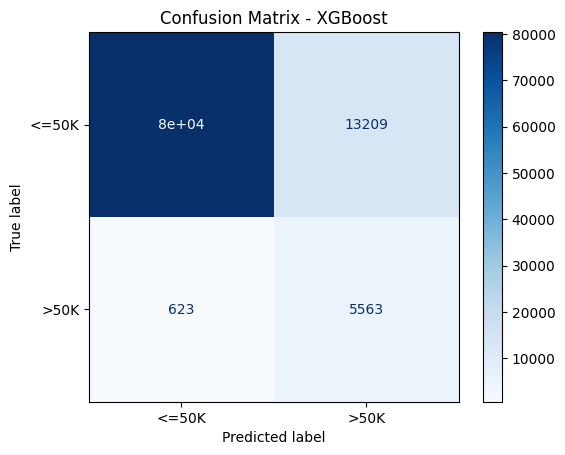

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict on your test set
y_pred = xgb.predict(test_X)

# Create the confusion matrix
cm = confusion_matrix(test_y, y_pred)

# Display the confusion matrix with labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<=50K', '>50K'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - XGBoost")
plt.show()

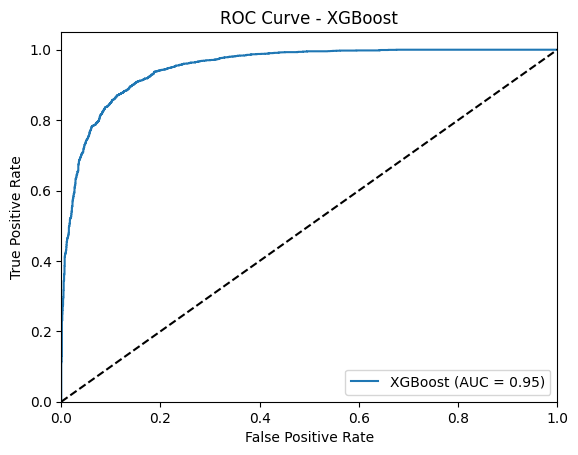

In [50]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities for the positive class (class 1: >50K)
xgb_probs = xgb.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC for XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs, pos_label=1)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# Plot ROC curve for XGBoost
plt.figure()
plt.plot(fpr_xgb, tpr_xgb, label='XGBoost (AUC = %0.2f)' % roc_auc_xgb)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend(loc="lower right")
plt.show()
